# SUMO Traffic Light Control - Training Analysis

This notebook analyzes training metrics from DQN agent training runs.
It loads metrics from the `output/` directory and provides comprehensive visualizations.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Optional
import glob

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuration
OUTPUT_DIR = Path("output")

print("Libraries imported successfully!")


Libraries imported successfully!


## Load Training Metrics

Select a run ID or load the most recent run automatically.


In [2]:
def load_metrics(run_id: Optional[str] = None) -> tuple[Dict, Dict, Path]:
    """Load metrics and config for a specific run."""
    if run_id is None:
        # Find most recent run
        runs = sorted(OUTPUT_DIR.glob("*/"), key=lambda p: p.stat().st_mtime, reverse=True)
        if not runs:
            raise ValueError(f"No runs found in {OUTPUT_DIR}")
        run_dir = runs[0]
        run_id = run_dir.name
        print(f"Loading most recent run: {run_id}")
    else:
        run_dir = OUTPUT_DIR / run_id
    
    metrics_file = run_dir / "metrics.json"
    config_file = run_dir / "config.json"
    
    if not metrics_file.exists():
        raise FileNotFoundError(f"Metrics file not found: {metrics_file}")
    
    with open(metrics_file) as f:
        metrics = json.load(f)
    
    config = {}
    if config_file.exists():
        with open(config_file) as f:
            config = json.load(f)
    
    return metrics, config, run_dir

# Load metrics (change run_id to analyze a specific run)
RUN_ID = None  # Set to specific run_id like "20251106_181903_0af7387f" or None for most recent
metrics, config, run_dir = load_metrics(RUN_ID)

print(f"\nLoaded metrics for run: {metrics.get('run_id', 'unknown')}")
print(f"Mode: {metrics.get('mode', 'unknown')}")
print(f"Episodes: {metrics.get('episodes', 0)}")


Loading most recent run: 20251106_192848_00f95735

Loaded metrics for run: 20251106_192848_00f95735
Mode: training
Episodes: 100


## Convert to DataFrame

Convert episode data to a pandas DataFrame for easier analysis.


In [3]:
if metrics.get('mode') == 'training' and 'episode_data' in metrics:
    df = pd.DataFrame(metrics['episode_data'])
    
    # Calculate additional metrics
    df['avg_queue_per_lane'] = df['queues'].apply(lambda x: np.mean(x) if x else 0)
    df['max_queue'] = df['queues'].apply(lambda x: max(x) if x else 0)
    df['avg_waiting_per_lane'] = df['waiting_times'].apply(lambda x: np.mean(x) if x else 0)
    df['max_waiting'] = df['waiting_times'].apply(lambda x: max(x) if x else 0)
    
    # Calculate moving averages
    window = min(10, len(df) // 4)
    df['reward_ma'] = df['reward'].rolling(window=window, center=True).mean()
    df['queues_ma'] = df['total_queues'].rolling(window=window, center=True).mean()
    df['waiting_ma'] = df['total_waiting_time'].rolling(window=window, center=True).mean()
    
    if 'avg_loss' in df.columns:
        df['loss_ma'] = df['avg_loss'].rolling(window=window, center=True).mean()
    
    print(f"DataFrame shape: {df.shape}")
    print(f"\nFirst few episodes:")
    print(df[['episode', 'reward', 'epsilon', 'total_queues', 'total_waiting_time']].head())
    print(f"\nLast few episodes:")
    print(df[['episode', 'reward', 'epsilon', 'total_queues', 'total_waiting_time']].tail())
else:
    print("No training episode data found. This might be an evaluation-only run.")
    df = None


DataFrame shape: (100, 18)

First few episodes:
   episode    reward  epsilon  total_queues  total_waiting_time
0        1 -48630.80     1.00            41              6710.0
1        2 -63749.05     0.05            42              3960.0
2        3 -20666.90     0.05            29              1222.0
3        4 -76982.80     0.05            34              6685.0
4        5  -7687.65     0.05            30              1738.0

Last few episodes:
    episode     reward  epsilon  total_queues  total_waiting_time
95       96  -72747.15     0.05            37              1792.0
96       97 -104286.30     0.05            38              8193.0
97       98  -31120.85     0.05            48              5077.0
98       99  -93401.35     0.05            37              3665.0
99      100  -76941.00     0.05            31              1214.0


## Training Overview

Display key statistics about the training run.


In [4]:
if df is not None:
    print("=" * 80)
    print("TRAINING OVERVIEW")
    print("=" * 80)
    print(f"\nRun ID: {metrics.get('run_id')}")
    print(f"Total Episodes: {len(df)}")
    print(f"\nReward Statistics:")
    print(f"  Initial (first 10): {df.head(10)['reward'].mean():.2f}")
    print(f"  Final (last 10): {df.tail(10)['reward'].mean():.2f}")
    print(f"  Best: {df['reward'].max():.2f}")
    print(f"  Worst: {df['reward'].min():.2f}")
    print(f"  Mean: {df['reward'].mean():.2f}")
    print(f"  Std: {df['reward'].std():.2f}")
    
    print(f"\nQueue Statistics:")
    print(f"  Initial (first 10): {df.head(10)['total_queues'].mean():.1f}")
    print(f"  Final (last 10): {df.tail(10)['total_queues'].mean():.1f}")
    print(f"  Best (lowest): {df['total_queues'].min():.0f}")
    print(f"  Worst (highest): {df['total_queues'].max():.0f}")
    
    print(f"\nWaiting Time Statistics:")
    print(f"  Initial (first 10): {df.head(10)['total_waiting_time'].mean():.2f}s")
    print(f"  Final (last 10): {df.tail(10)['total_waiting_time'].mean():.2f}s")
    print(f"  Best (lowest): {df['total_waiting_time'].min():.2f}s")
    
    print(f"\nEpsilon (Exploration):")
    print(f"  Start: {df['epsilon'].iloc[0]:.3f}")
    print(f"  End: {df['epsilon'].iloc[-1]:.3f}")
    
    if 'avg_loss' in df.columns and df['avg_loss'].notna().any():
        loss_data = df[df['avg_loss'].notna()]
        if len(loss_data) > 0:
            print(f"\nLoss Statistics:")
            print(f"  Mean: {loss_data['avg_loss'].mean():.6f}")
            print(f"  Final: {loss_data['avg_loss'].iloc[-1]:.6f}")
    
    if 'best_eval_reward' in metrics and metrics['best_eval_reward']:
        print(f"\nBest Evaluation Reward: {metrics['best_eval_reward']:.2f}")


TRAINING OVERVIEW

Run ID: 20251106_192848_00f95735
Total Episodes: 100

Reward Statistics:
  Initial (first 10): -59600.20
  Final (last 10): -88045.71
  Best: -7687.65
  Worst: -149860.10
  Mean: -78305.46
  Std: 29483.84

Queue Statistics:
  Initial (first 10): 37.5
  Final (last 10): 39.9
  Best (lowest): 19
  Worst (highest): 60

Waiting Time Statistics:
  Initial (first 10): 4560.70s
  Final (last 10): 4592.80s
  Best (lowest): 180.00s

Epsilon (Exploration):
  Start: 1.000
  End: 0.050

Loss Statistics:
  Mean: 221913.786303
  Final: 325184.084160


## Visualization: Reward Over Time

Plot episode rewards to see learning progress.


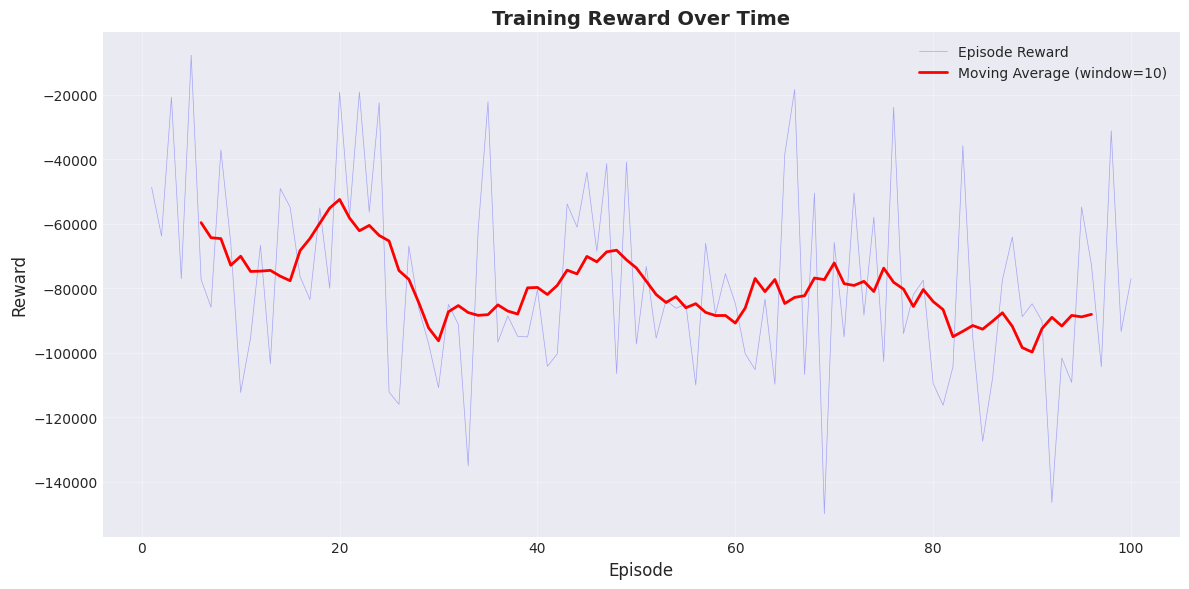

In [5]:
if df is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(df['episode'], df['reward'], alpha=0.3, label='Episode Reward', color='blue', linewidth=0.5)
    if 'reward_ma' in df.columns:
        ax.plot(df['episode'], df['reward_ma'], label=f'Moving Average (window={window})', 
                color='red', linewidth=2)
    
    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('Reward', fontsize=12)
    ax.set_title('Training Reward Over Time', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## Visualization: Queue Length Over Time

Track how queue lengths change during training.


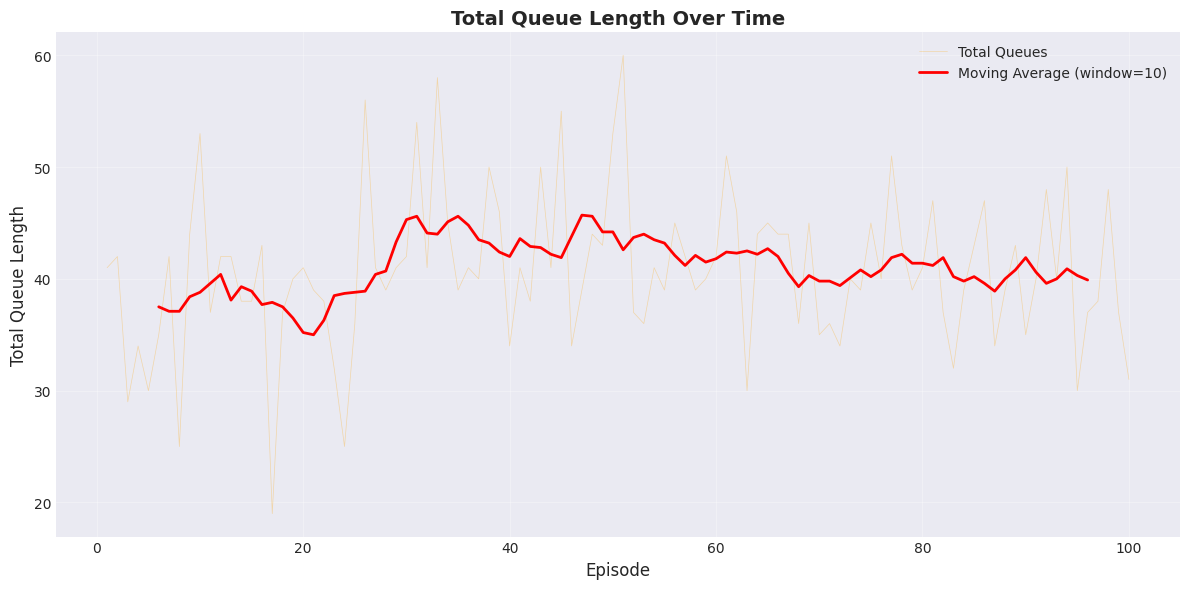

In [6]:
if df is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(df['episode'], df['total_queues'], alpha=0.3, label='Total Queues', 
            color='orange', linewidth=0.5)
    if 'queues_ma' in df.columns:
        ax.plot(df['episode'], df['queues_ma'], label=f'Moving Average (window={window})', 
                color='red', linewidth=2)
    
    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('Total Queue Length', fontsize=12)
    ax.set_title('Total Queue Length Over Time', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## Visualization: Waiting Time Over Time

Monitor waiting times to assess traffic flow improvement.


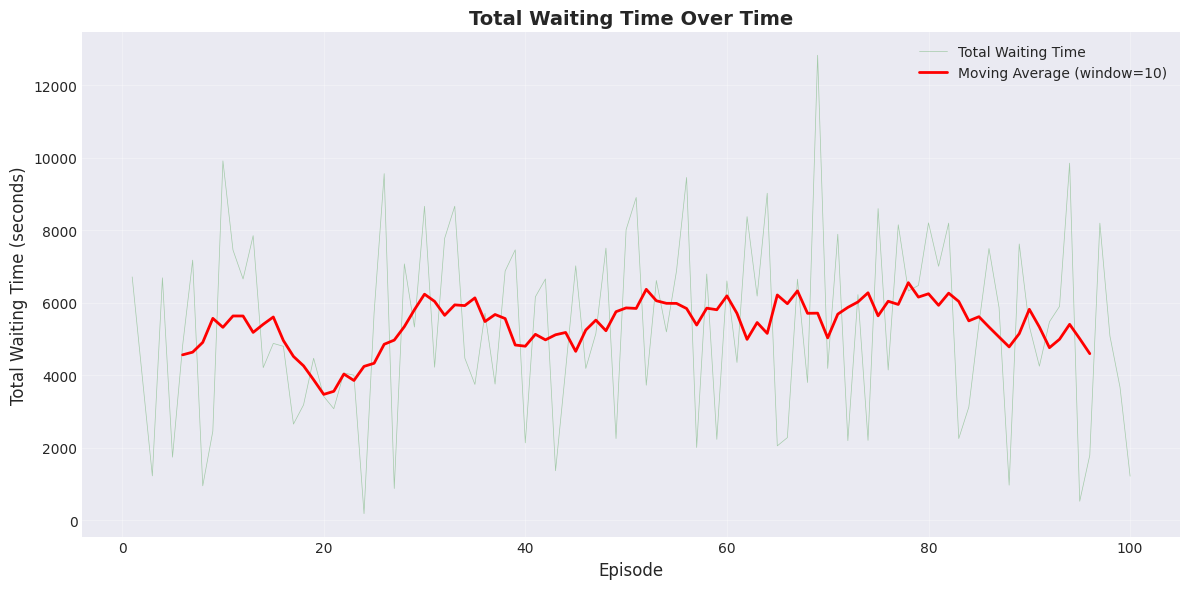

In [7]:
if df is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(df['episode'], df['total_waiting_time'], alpha=0.3, label='Total Waiting Time', 
            color='green', linewidth=0.5)
    if 'waiting_ma' in df.columns:
        ax.plot(df['episode'], df['waiting_ma'], label=f'Moving Average (window={window})', 
                color='red', linewidth=2)
    
    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('Total Waiting Time (seconds)', fontsize=12)
    ax.set_title('Total Waiting Time Over Time', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## Visualization: Epsilon (Exploration Rate)

Track how exploration decreases over time as the agent becomes more confident.


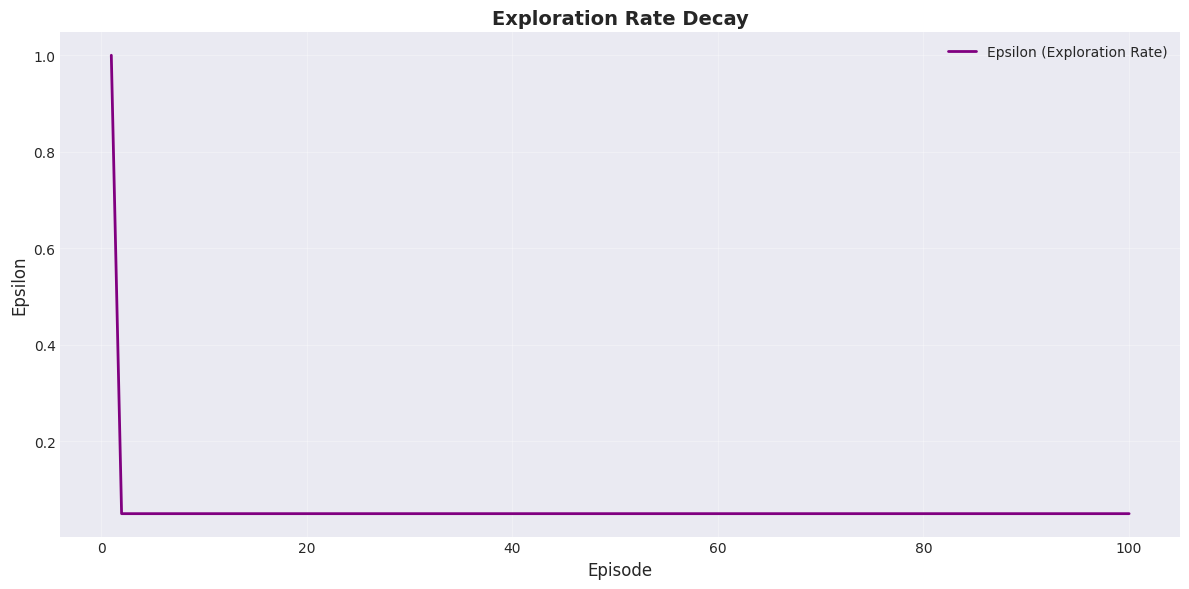

In [8]:
if df is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(df['episode'], df['epsilon'], label='Epsilon (Exploration Rate)', 
            color='purple', linewidth=2)
    
    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('Epsilon', fontsize=12)
    ax.set_title('Exploration Rate Decay', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## Visualization: Training Loss

If available, plot the training loss to monitor learning stability.


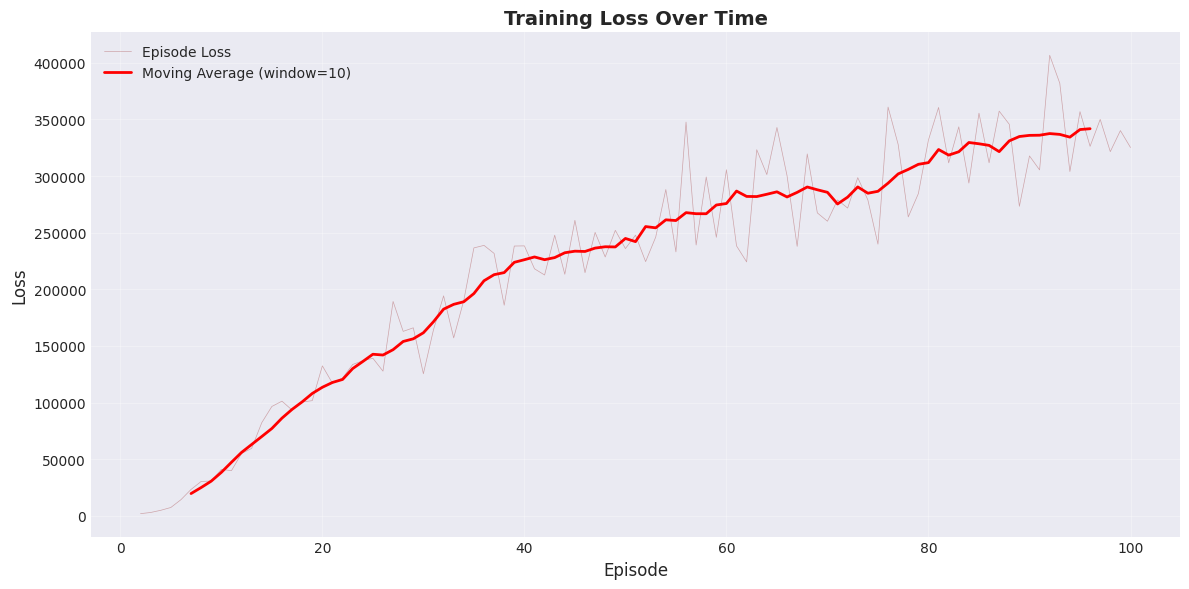

In [9]:
if df is not None and 'avg_loss' in df.columns and df['avg_loss'].notna().any():
    loss_data = df[df['avg_loss'].notna()]
    
    if len(loss_data) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        
        ax.plot(loss_data['episode'], loss_data['avg_loss'], alpha=0.3, 
                label='Episode Loss', color='darkred', linewidth=0.5)
        if 'loss_ma' in loss_data.columns:
            ax.plot(loss_data['episode'], loss_data['loss_ma'], 
                    label=f'Moving Average (window={window})', color='red', linewidth=2)
        
        ax.set_xlabel('Episode', fontsize=12)
        ax.set_ylabel('Loss', fontsize=12)
        ax.set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print("No loss data available.")
else:
    print("Loss tracking not available in this run.")


## Visualization: Action Distribution

Analyze which actions the agent prefers over time.


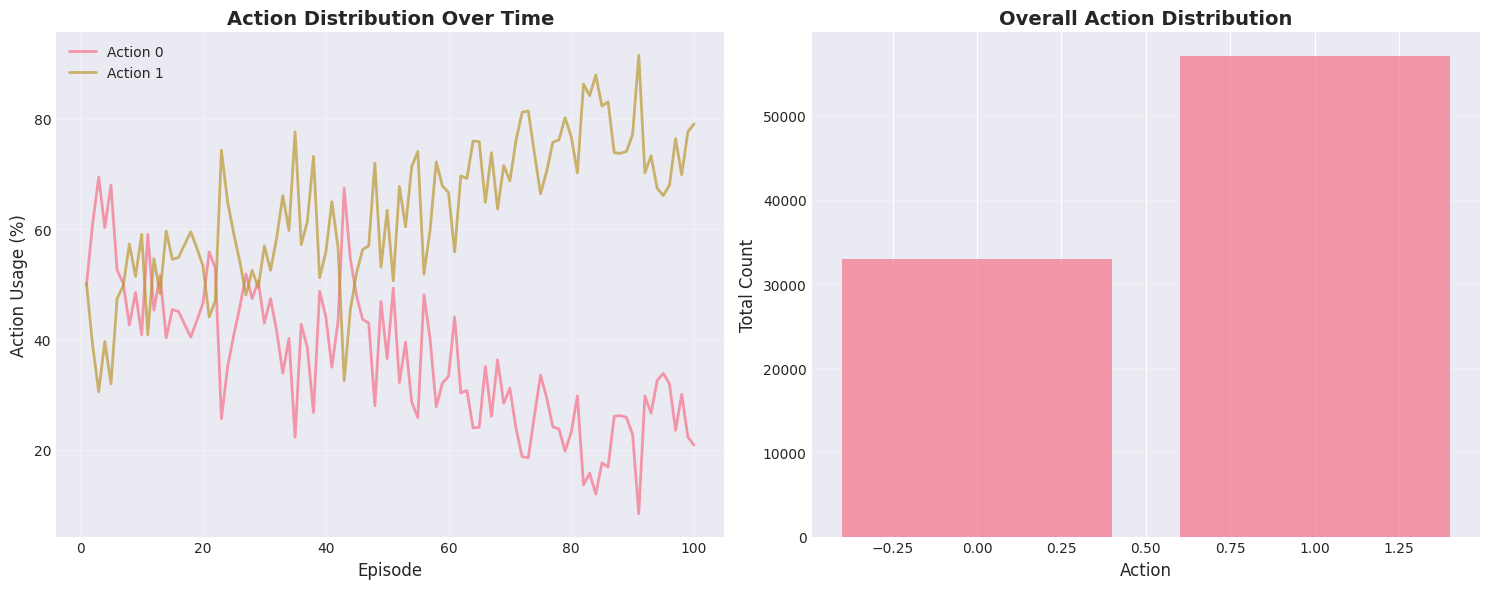

In [10]:
if df is not None and 'action_distribution' in df.columns:
    # Extract action distributions
    action_data = []
    for idx, row in df.iterrows():
        dist = row['action_distribution']
        if dist:
            for action, count in dist.items():
                action_data.append({
                    'episode': row['episode'],
                    'action': int(action),
                    'count': count,
                    'percentage': count / sum(dist.values()) * 100
                })
    
    if action_data:
        action_df = pd.DataFrame(action_data)
        
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Plot 1: Action usage over time
        for action in sorted(action_df['action'].unique()):
            action_subset = action_df[action_df['action'] == action]
            axes[0].plot(action_subset['episode'], action_subset['percentage'], 
                        label=f'Action {action}', linewidth=2, alpha=0.7)
        
        axes[0].set_xlabel('Episode', fontsize=12)
        axes[0].set_ylabel('Action Usage (%)', fontsize=12)
        axes[0].set_title('Action Distribution Over Time', fontsize=14, fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot 2: Overall action distribution
        overall_dist = action_df.groupby('action')['count'].sum()
        axes[1].bar(overall_dist.index, overall_dist.values, alpha=0.7)
        axes[1].set_xlabel('Action', fontsize=12)
        axes[1].set_ylabel('Total Count', fontsize=12)
        axes[1].set_title('Overall Action Distribution', fontsize=14, fontweight='bold')
        axes[1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No action distribution data available.")
else:
    print("Action distribution tracking not available in this run.")


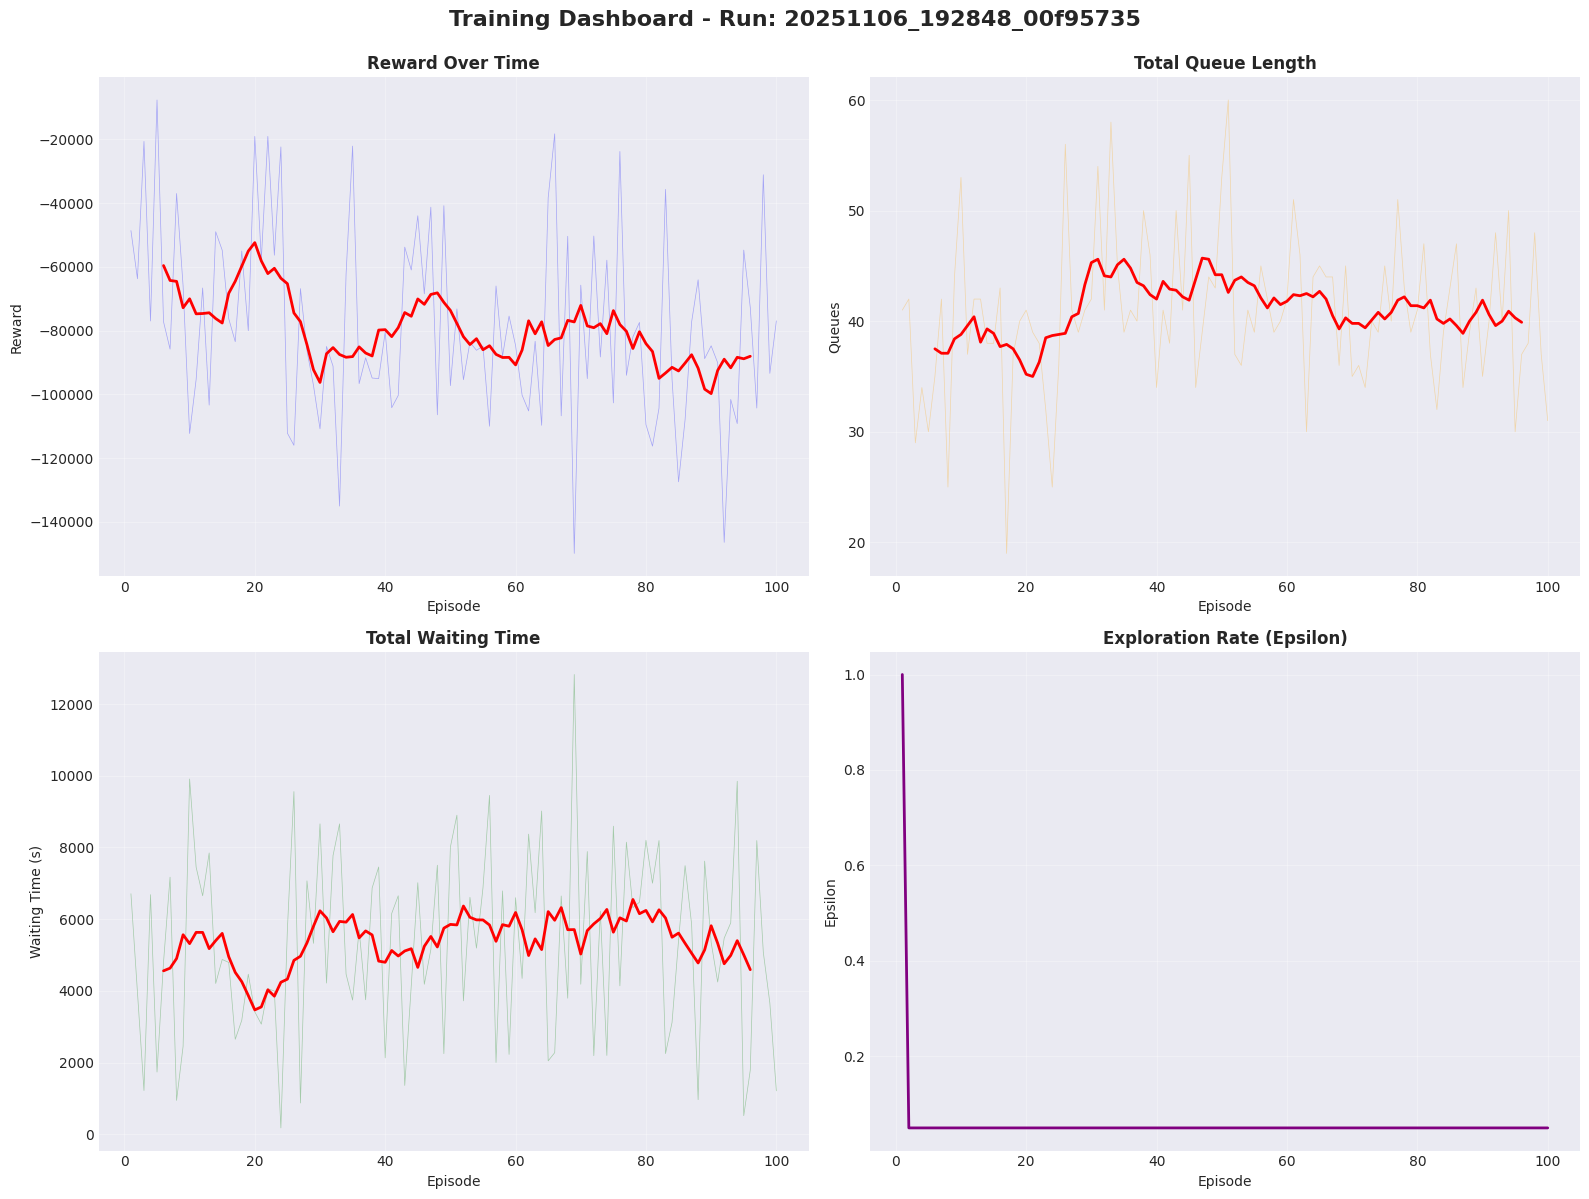

In [11]:
if df is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Reward
    axes[0, 0].plot(df['episode'], df['reward'], alpha=0.3, color='blue', linewidth=0.5)
    if 'reward_ma' in df.columns:
        axes[0, 0].plot(df['episode'], df['reward_ma'], color='red', linewidth=2)
    axes[0, 0].set_title('Reward Over Time', fontweight='bold')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Reward')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Queues
    axes[0, 1].plot(df['episode'], df['total_queues'], alpha=0.3, color='orange', linewidth=0.5)
    if 'queues_ma' in df.columns:
        axes[0, 1].plot(df['episode'], df['queues_ma'], color='red', linewidth=2)
    axes[0, 1].set_title('Total Queue Length', fontweight='bold')
    axes[0, 1].set_xlabel('Episode')
    axes[0, 1].set_ylabel('Queues')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Waiting Time
    axes[1, 0].plot(df['episode'], df['total_waiting_time'], alpha=0.3, color='green', linewidth=0.5)
    if 'waiting_ma' in df.columns:
        axes[1, 0].plot(df['episode'], df['waiting_ma'], color='red', linewidth=2)
    axes[1, 0].set_title('Total Waiting Time', fontweight='bold')
    axes[1, 0].set_xlabel('Episode')
    axes[1, 0].set_ylabel('Waiting Time (s)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Epsilon
    axes[1, 1].plot(df['episode'], df['epsilon'], color='purple', linewidth=2)
    axes[1, 1].set_title('Exploration Rate (Epsilon)', fontweight='bold')
    axes[1, 1].set_xlabel('Episode')
    axes[1, 1].set_ylabel('Epsilon')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Training Dashboard - Run: {metrics.get("run_id", "unknown")}', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()


## Per-Lane Analysis

Analyze performance for individual lanes.


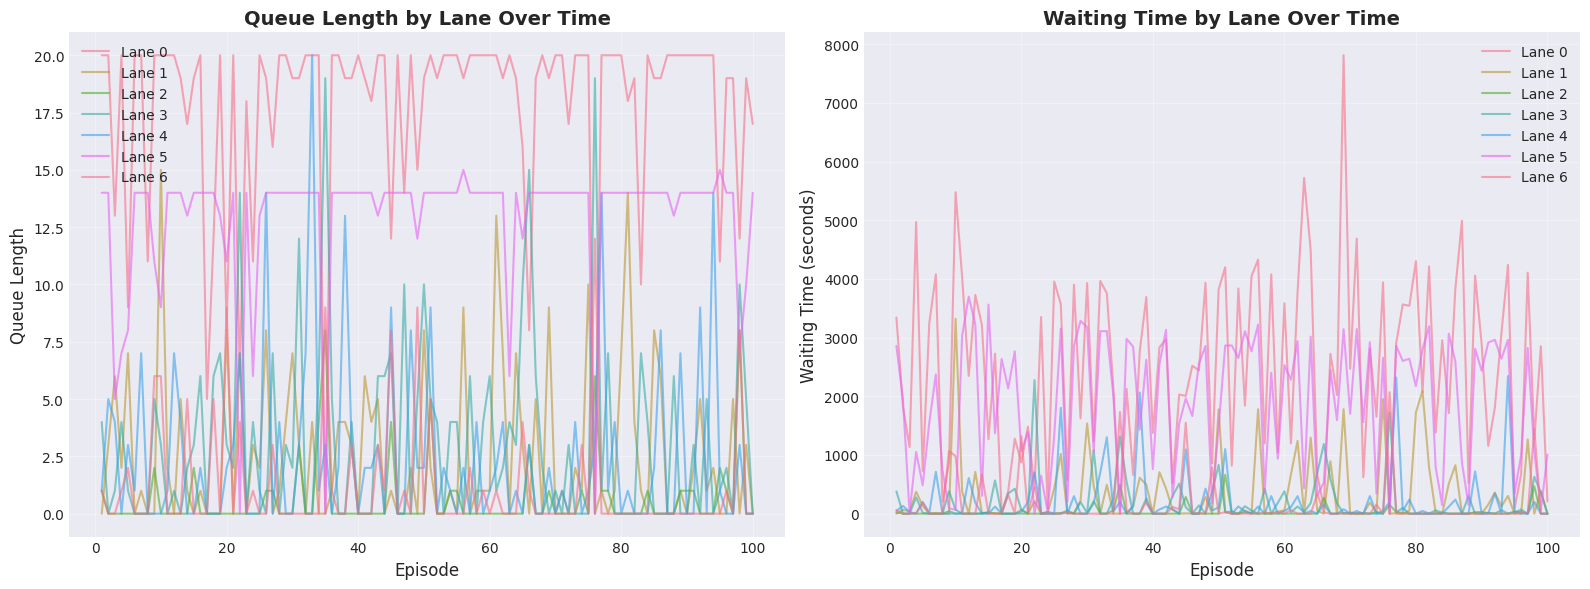

In [12]:
if df is not None and 'queues' in df.columns:
    # Extract per-lane data
    num_lanes = len(df['queues'].iloc[0]) if len(df) > 0 and df['queues'].iloc[0] else 0
    
    if num_lanes > 0:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Per-lane queues over time
        for lane_idx in range(num_lanes):
            lane_queues = df['queues'].apply(lambda x: x[lane_idx] if len(x) > lane_idx else 0)
            axes[0].plot(df['episode'], lane_queues, alpha=0.6, label=f'Lane {lane_idx}', linewidth=1.5)
        
        axes[0].set_xlabel('Episode', fontsize=12)
        axes[0].set_ylabel('Queue Length', fontsize=12)
        axes[0].set_title('Queue Length by Lane Over Time', fontsize=14, fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Per-lane waiting times over time
        for lane_idx in range(num_lanes):
            lane_waiting = df['waiting_times'].apply(lambda x: x[lane_idx] if len(x) > lane_idx else 0)
            axes[1].plot(df['episode'], lane_waiting, alpha=0.6, label=f'Lane {lane_idx}', linewidth=1.5)
        
        axes[1].set_xlabel('Episode', fontsize=12)
        axes[1].set_ylabel('Waiting Time (seconds)', fontsize=12)
        axes[1].set_title('Waiting Time by Lane Over Time', fontsize=14, fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print("No per-lane data available.")
else:
    print("Per-lane analysis not available.")


## Evaluation Metrics (if available)

If periodic evaluations were performed, analyze those results.


In [13]:
if 'evaluation_data' in metrics and metrics['evaluation_data']:
    eval_df = pd.DataFrame([
        {
            'episode': eval_data['episode'],
            'avg_reward': eval_data['metrics']['avg_reward'],
            'avg_queues': eval_data['metrics']['avg_total_queues'],
            'avg_waiting': eval_data['metrics']['avg_total_waiting_time']
        }
        for eval_data in metrics['evaluation_data']
    ])
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(eval_df['episode'], eval_df['avg_reward'], marker='o', linewidth=2, markersize=8)
    axes[0].set_title('Evaluation Reward', fontweight='bold')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Average Reward')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(eval_df['episode'], eval_df['avg_queues'], marker='o', linewidth=2, markersize=8, color='orange')
    axes[1].set_title('Evaluation Queues', fontweight='bold')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Average Queues')
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(eval_df['episode'], eval_df['avg_waiting'], marker='o', linewidth=2, markersize=8, color='green')
    axes[2].set_title('Evaluation Waiting Time', fontweight='bold')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylabel('Average Waiting Time (s)')
    axes[2].grid(True, alpha=0.3)
    
    plt.suptitle('Periodic Evaluation Results', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\nEvaluation Summary:")
    print(eval_df.describe())
else:
    print("No evaluation data available (--eval-every was not used).")


No evaluation data available (--eval-every was not used).


## Configuration Summary

Display the training configuration used for this run.


In [14]:
print("=" * 80)
print("TRAINING CONFIGURATION")
print("=" * 80)

if config:
    for key, value in config.items():
        print(f"{key:25s}: {value}")
else:
    print("Configuration file not found.")

if 'config' in metrics:
    print("\nAdditional Metrics Config:")
    for key, value in metrics['config'].items():
        print(f"{key:25s}: {value}")


TRAINING CONFIGURATION
run_id                   : 20251106_192848_00f95735
episodes                 : 100
max_steps                : 900
step_length              : 1.0
seed                     : None
learning_rate            : 0.001
batch_size               : 64
replay_size              : 50000
target_update            : 200
eval_every               : 0
eval_episodes            : 5
osm_file                 : maps/sanFrancisco.osm
flow_rate                : 800
tls_id                   : None
device                   : cpu

Additional Metrics Config:
learning_rate            : 0.001
batch_size               : 64
replay_size              : 50000
target_update            : 200
flow_rate                : 800
osm_file                 : maps/sanFrancisco.osm
tls_id                   : None


## Compare Multiple Runs

Load and compare multiple training runs side by side.


In [15]:
def compare_runs(run_ids: List[str]) -> None:
    """Compare multiple training runs."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    for run_id in run_ids:
        try:
            metrics, config, _ = load_metrics(run_id)
            if metrics.get('mode') == 'training' and 'episode_data' in metrics:
                df = pd.DataFrame(metrics['episode_data'])
                
                window = min(10, len(df) // 4)
                df['reward_ma'] = df['reward'].rolling(window=window, center=True).mean()
                df['queues_ma'] = df['total_queues'].rolling(window=window, center=True).mean()
                
                label = f"{run_id[:15]}..."
                
                axes[0, 0].plot(df['episode'], df['reward_ma'], label=label, linewidth=2)
                axes[0, 1].plot(df['episode'], df['queues_ma'], label=label, linewidth=2)
                axes[1, 0].plot(df['episode'], df['total_waiting_time'], label=label, linewidth=2, alpha=0.7)
                axes[1, 1].plot(df['episode'], df['epsilon'], label=label, linewidth=2)
        except Exception as e:
            print(f"Error loading run {run_id}: {e}")
    
    axes[0, 0].set_title('Reward Comparison', fontweight='bold')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Reward (MA)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].set_title('Queue Comparison', fontweight='bold')
    axes[0, 1].set_xlabel('Episode')
    axes[0, 1].set_ylabel('Queues (MA)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].set_title('Waiting Time Comparison', fontweight='bold')
    axes[1, 0].set_xlabel('Episode')
    axes[1, 0].set_ylabel('Waiting Time (s)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].set_title('Epsilon Comparison', fontweight='bold')
    axes[1, 1].set_xlabel('Episode')
    axes[1, 1].set_ylabel('Epsilon')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Uncomment and modify to compare specific runs:
# compare_runs(["run_id_1", "run_id_2", "run_id_3"])
